# CNN + LSTM — Sign Language Recognition (Dataset 2)

Uses the frozen ASLCNN from Dataset 1 as a frame-level feature extractor.
The 512-d bottleneck vector (layer just before the final classifier) is extracted
per frame, stacked into sequences, then fed into a Bidirectional LSTM.

Dataset 2 structure:
```
ASL_dynamic/
  A/
    video_01/   ← folder of frame images  (we use this)
    video_01_frame_folder/  ← ignored
    ...
  HELLO/
  THANKYOU/
  ...
```

Split strategy: stratified train/test split first (held-out test never touched),
then K-Fold cross-validation on the training portion only.

## Cell 1 — Imports

In [28]:
import os
import copy
import time
import random
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler
from torchvision import transforms
from PIL import Image

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEM = torch.cuda.is_available()
print('Device:', DEVICE)

Device: cuda


## Cell 2 — Configuration

In [29]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATASET2_ROOT = Path('/kaggle/input/datasets/ep25b021/dataset-2/ASL_dynamic')
CNN_WEIGHTS   = Path('/kaggle/input/datasets/ep25b021/cnn-weights/asl_cnn_weights.pth')
OUTPUT_DIR    = Path('/kaggle/working')

# ── Frame sampling ─────────────────────────────────────────────────────────
T        = 16       # fixed frames per video (uniform temporal sampling)
IMG_SIZE = 64       # must match CNN training size

# ── LSTM hyperparameters ───────────────────────────────────────────────────
FEATURE_DIM  = 512  # CNN bottleneck output dimension
LSTM_HIDDEN  = 256
LSTM_LAYERS  = 2
DROPOUT      = 0.4
LR           = 3e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 16
EPOCHS       = 80
PATIENCE     = 15

# ── Split / CV ─────────────────────────────────────────────────────────────
TEST_SPLIT = 0.15   # fraction held out as final test set (never seen during CV)
K_FOLDS    = 5      # K for cross-validation on train portion

print('Config loaded.')

Config loaded.


## Cell 3 — Rebuild ASLCNN architecture (copy-pasted from your CNN file)

In [30]:
# Exact same architecture as asl_cnn__1_.py — do not change anything here.
# We load the trained weights into this definition.

class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel,
                      stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = ConvBnRelu(in_ch,  out_ch, stride=stride)
        self.conv2 = ConvBnRelu(out_ch, out_ch, stride=1)
        self.skip  = nn.Sequential()
        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
    def forward(self, x):
        return nn.functional.relu(self.conv2(self.conv1(x)) + self.skip(x), inplace=True)


class SpatialPyramidPooling(nn.Module):
    def __init__(self, levels=(1, 2, 4)):
        super().__init__()
        self.levels = levels
    def forward(self, x):
        B = x.size(0)
        return torch.cat(
            [nn.functional.adaptive_avg_pool2d(x, lvl).view(B, -1) for lvl in self.levels],
            dim=1
        )


class ASLCNN(nn.Module):
    def __init__(self, num_classes=36, dropout=0.4):
        super().__init__()
        self.stem   = ConvBnRelu(3, 32)
        self.block1 = nn.Sequential(ResidualBlock(32,  64),  nn.MaxPool2d(2,2), nn.Dropout2d(0.10))
        self.block2 = nn.Sequential(ResidualBlock(64,  128), nn.MaxPool2d(2,2), nn.Dropout2d(0.15))
        self.block3 = nn.Sequential(ResidualBlock(128, 256), nn.MaxPool2d(2,2), nn.Dropout2d(0.20))
        self.block4 = nn.Sequential(ResidualBlock(256, 512), nn.MaxPool2d(2,2), nn.Dropout2d(0.20))
        self.spp    = SpatialPyramidPooling(levels=(1, 2, 4))
        spp_dim     = 512 * (1 + 4 + 16)  # 10,752
        self.classifier = nn.Sequential(
            nn.Linear(spp_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(1024, 512),     nn.BatchNorm1d(512),  nn.ReLU(inplace=True), nn.Dropout(dropout/2),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.spp(x)
        return self.classifier(x)

print('Architecture defined.')

Architecture defined.


## Cell 4 — Load CNN weights and create feature extractor

In [31]:
# Load checkpoint
ckpt = torch.load(CNN_WEIGHTS, map_location=DEVICE)
print('Checkpoint keys :', list(ckpt.keys()))
print('CNN class names  :', ckpt['class_names'])
print('CNN num_classes  :', ckpt['num_classes'])

cnn_full = ASLCNN(num_classes=ckpt['num_classes']).to(DEVICE)
cnn_full.load_state_dict(ckpt['model_state_dict'])
cnn_full.eval()

# ── Feature extractor: everything up to (but NOT including) the final Linear ──
# classifier = [Linear→BN→ReLU→Drop, Linear→BN→ReLU→Drop, Linear(512→num_classes)]
# We want the 512-d output just before the last linear, so we keep indices 0..5
# (i.e. the first two sub-blocks of self.classifier)

class CNNFeatureExtractor(nn.Module):
    """Wraps ASLCNN and returns the 512-d pre-logit feature vector."""
    def __init__(self, full_model: ASLCNN):
        super().__init__()
        self.backbone   = nn.Sequential(
            full_model.stem,
            full_model.block1,
            full_model.block2,
            full_model.block3,
            full_model.block4,
            full_model.spp,
        )
        # first two FC sub-blocks (Linear→BN→ReLU→Drop twice) → 512-d
        self.neck = full_model.classifier[:-1]   # drop the final Linear

    def forward(self, x):
        x = self.backbone(x)   # (B, 10752)
        x = self.neck(x)       # (B, 512)
        return x

feature_extractor = CNNFeatureExtractor(cnn_full).to(DEVICE)
feature_extractor.eval()

# Freeze — no gradient updates on CNN
for p in feature_extractor.parameters():
    p.requires_grad = False

# Quick sanity check
with torch.no_grad():
    _dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out   = feature_extractor(_dummy)
    assert _out.shape == (2, FEATURE_DIM), f'Expected (2,512), got {_out.shape}'
    del _dummy, _out

print(f'Feature extractor ready. Output dim = {FEATURE_DIM}')

Checkpoint keys : ['model_state_dict', 'class_names', 'num_classes', 'img_size', 'best_val_acc']
CNN class names  : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
CNN num_classes  : 36
Feature extractor ready. Output dim = 512


## Cell 5 — Discover Dataset 2 structure

In [32]:
# ── Cell 5 replacement — handles both frame folders AND raw video files ──

import cv2

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
VIDEO_EXTS = {'.mp4', '.avi', '.mov', '.mkv'}

def classify_subfolder(path: Path):
    """
    Returns:
      ('frames', path)  if path is a dir containing images
      ('video',  path)  if path is a video file
      None              otherwise
    """
    if path.is_dir() and any(f.suffix.lower() in IMAGE_EXTS for f in path.iterdir()):
        return ('frames', path)
    if path.is_file() and path.suffix.lower() in VIDEO_EXTS:
        return ('video', path)
    return None

class_names     = sorted([d.name for d in DATASET2_ROOT.iterdir() if d.is_dir()])
class_to_videos = defaultdict(list)   # class -> list of ('frames'|'video', Path)

for cls in class_names:
    for item in sorted((DATASET2_ROOT / cls).iterdir()):
        result = classify_subfolder(item)
        if result is not None:
            class_to_videos[cls].append(result)

print(f'Classes found ({len(class_names)}): {class_names}\n')
print(f'{"Class":<14} {"Videos":>7}  {"Type":<10}  Frame range')
print('-' * 55)
for cls in class_names:
    entries = class_to_videos[cls]
    if not entries:
        print(f'{cls:<14}       0  ← STILL EMPTY, check manually')
        continue
    types = set(t for t, _ in entries)
    # Count frames per entry for display
    fc = []
    for kind, path in entries:
        if kind == 'frames':
            fc.append(sum(1 for f in path.iterdir() if f.suffix.lower() in IMAGE_EXTS))
        else:
            cap = cv2.VideoCapture(str(path))
            fc.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
            cap.release()
    print(f'{cls:<14} {len(entries):>7}  {str(types):<10}  min={min(fc)} max={max(fc)}')

Classes found (31): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'HELLO', 'I', 'J', 'K', 'L', 'M', 'N', 'NO', 'O', 'P', 'Q', 'R', 'S', 'SORRY', 'T', 'THANKYOU', 'U', 'V', 'W', 'X', 'Y', 'YES', 'Z']

Class           Videos  Type        Frame range
-------------------------------------------------------
A                   20  {'frames', 'video'}  min=85 max=102
B                   20  {'frames', 'video'}  min=65 max=115
C                   20  {'frames', 'video'}  min=17 max=94
D                   20  {'frames', 'video'}  min=32 max=52
E                   20  {'frames', 'video'}  min=28 max=115
F                   20  {'frames', 'video'}  min=28 max=115
G                   20  {'frames', 'video'}  min=20 max=114
H                   20  {'frames', 'video'}  min=34 max=113
HELLO               20  {'frames', 'video'}  min=132 max=159
I                   20  {'frames', 'video'}  min=34 max=112
J                   20  {'frames', 'video'}  min=31 max=114
K                   20  {'frames', 'video'

## Cell 6 — Uniform temporal sampling helper

In [33]:
# ── Cell 6 replacement — sample_frames works for both types ──
# ── Add this at the top of Cell 6 ──

frame_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])
def sample_frames(entry, t: int) -> list:
    """
    entry: ('frames', Path) or ('video', Path)
    Returns a list of t items — either image Paths or numpy arrays (H,W,3) RGB.
    Also returns the source type so the loader knows how to open them.
    """
    kind, path = entry

    if kind == 'frames':
        frames = sorted(
            [f for f in path.iterdir() if f.suffix.lower() in IMAGE_EXTS]
        )
        n = len(frames)
        if n == 0:
            return kind, []
        indices = np.round(np.linspace(0, n - 1, t)).astype(int)
        return kind, [frames[i] for i in indices]

    else:  # raw video file
        cap = cv2.VideoCapture(str(path))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.round(np.linspace(0, total - 1, t)).astype(int)
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            else:
                frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))
        cap.release()
        return kind, frames


# Update Cell 7's inner loop to use the new sample_frames signature:
# Replace the extraction block inside Cell 7 with this:

def extract_features_from_entry(entry, t: int) -> np.ndarray:
    """Returns (T, 512) CNN feature array for one video entry."""
    kind, items = sample_frames(entry, t)

    if len(items) < t:
        return None

    if kind == 'frames':
        imgs = torch.stack([
            frame_transform(Image.open(fp).convert('RGB')) for fp in items
        ]).to(DEVICE)
    else:  # numpy arrays from cv2
        imgs = torch.stack([
            frame_transform(Image.fromarray(arr)) for arr in items
        ]).to(DEVICE)

    with torch.no_grad():
        feats = feature_extractor(imgs)   # (T, 512)
    return feats.cpu().numpy()

## Cell 7 — Extract CNN features for every video (pre-compute & cache)

This loops over every video folder, samples T frames, runs them through
the frozen CNN in a single batch, and stores the (T, 512) feature tensor.
Pre-computing avoids re-running the CNN every training epoch.

In [34]:
CACHE_X = OUTPUT_DIR / 'cnn_features_X.npy'
CACHE_Y = OUTPUT_DIR / 'cnn_features_y.npy'

if CACHE_X.exists() and CACHE_Y.exists():
    # ── Load from cache (re-run skips extraction) ──────────────────────────
    X_all = np.load(CACHE_X)      # (N, T, 512)
    y_str = np.load(CACHE_Y)      # (N,) string labels
    print(f'Loaded from cache: X={X_all.shape}, y={y_str.shape}')

else:
    # ── Extract features ───────────────────────────────────────────────────
    X_list, y_list = [], []
    skipped = 0

    feature_extractor.eval()

    for cls in class_names:
        for entry in class_to_videos[cls]:
            feats = extract_features_from_entry(entry, T)
            if feats is None:
                print(f'  SKIP: {entry[1]}')
                skipped += 1
                continue
            X_list.append(feats)
            y_list.append(cls)

    X_all = np.array(X_list, dtype=np.float32)   # (N, T, 512)
    y_str = np.array(y_list)

    np.save(CACHE_X, X_all)
    np.save(CACHE_Y, y_str)

    print(f'\nExtraction done. Skipped: {skipped}')
    print(f'X shape : {X_all.shape}   y shape : {y_str.shape}')
    print(f'Cached to {CACHE_X}')


Extraction done. Skipped: 0
X shape : (590, 16, 512)   y shape : (590,)
Cached to /kaggle/working/cnn_features_X.npy


## Cell 8 — Encode labels, stratified train / test split

In [35]:
le = LabelEncoder()
y_enc = le.fit_transform(y_str)   # integer labels
NUM_CLASSES = len(le.classes_)

print(f'Classes ({NUM_CLASSES}): {list(le.classes_)}')

# Stratified split: test set is held out and NEVER touched during CV
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_enc,
    test_size=TEST_SPLIT,
    stratify=y_enc,
    random_state=SEED
)

print(f'Train+Val : {len(X_trainval)} samples')
print(f'Test      : {len(X_test)} samples')

# Save encoder
with open(OUTPUT_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Label encoder saved.')

Classes (31): [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('HELLO'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('NO'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('SORRY'), np.str_('T'), np.str_('THANKYOU'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('YES'), np.str_('Z')]
Train+Val : 501 samples
Test      : 89 samples
Label encoder saved.


## Cell 9 — Sequence-level data augmentation helpers

In [36]:
# Applied only to training folds, never to validation or test.
# Works on feature sequences (T, 512), not raw pixels.
#
#  1. Temporal jitter  — drop 1 random frame, re-sample back to T
#  2. Gaussian noise   — small perturbation on feature values
#  3. Time reversal    — reverse the frame order (mirrors the gesture)

def augment_sequence(seq: np.ndarray) -> np.ndarray:
    """seq: (T, 512) → augmented copy of same shape."""
    aug = seq.copy()
    t   = aug.shape[0]

    # 1. Temporal jitter
    if t > 2 and random.random() < 0.5:
        drop = random.randint(0, t - 1)
        aug  = np.delete(aug, drop, axis=0)
        idx  = np.round(np.linspace(0, len(aug)-1, t)).astype(int)
        aug  = aug[idx]

    # 2. Gaussian noise
    if random.random() < 0.5:
        aug += np.random.normal(0, 0.02, aug.shape).astype(np.float32)

    # 3. Time reversal
    if random.random() < 0.3:
        aug = aug[::-1].copy()

    return aug


def augment_fold(X_fold: np.ndarray, y_fold: np.ndarray):
    """Double the training fold with one augmented copy per sample."""
    X_aug = np.array([augment_sequence(s) for s in X_fold], dtype=np.float32)
    return (
        np.concatenate([X_fold, X_aug], axis=0),
        np.concatenate([y_fold, y_fold], axis=0)
    )

print('Augmentation helpers ready.')

Augmentation helpers ready.


## Cell 10 — LSTM model definition

In [37]:
class SignLSTM(nn.Module):
    """
    Bidirectional LSTM sequence classifier.
    Input : (B, T, FEATURE_DIM)  — pre-computed CNN features
    Output: (B, NUM_CLASSES)     — logits

    Architecture
    ────────────
    BiLSTM layer 1  (hidden=LSTM_HIDDEN, return sequences)
        → LayerNorm
    BiLSTM layer 2  (hidden=LSTM_HIDDEN//2, return last hidden)
        → LayerNorm
    FC 512 → 128 → NUM_CLASSES
    """
    def __init__(self, input_dim, hidden, n_layers, num_classes, dropout):
        super().__init__()

        self.lstm1 = nn.LSTM(
            input_dim, hidden,
            num_layers=1, batch_first=True,
            bidirectional=True, dropout=0
        )
        self.norm1 = nn.LayerNorm(hidden * 2)
        self.drop1 = nn.Dropout(dropout)

        self.lstm2 = nn.LSTM(
            hidden * 2, hidden // 2,
            num_layers=1, batch_first=True,
            bidirectional=True, dropout=0
        )
        self.norm2 = nn.LayerNorm(hidden)   # hidden//2 * 2 = hidden
        self.drop2 = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)

    def forward(self, x):
        # x: (B, T, input_dim)
        out, _  = self.lstm1(x)                   # (B, T, hidden*2)
        out     = self.drop1(self.norm1(out))
        out, _  = self.lstm2(out)                  # (B, T, hidden)
        out     = self.drop2(self.norm2(out))
        out     = out[:, -1, :]                    # take last time-step (B, hidden)
        return self.head(out)                      # (B, num_classes)


# Quick sanity check
_m = SignLSTM(FEATURE_DIM, LSTM_HIDDEN, LSTM_LAYERS, NUM_CLASSES, DROPOUT).to(DEVICE)
_d = torch.zeros(4, T, FEATURE_DIM).to(DEVICE)
assert _m(_d).shape == (4, NUM_CLASSES)
del _m, _d
print('LSTM model definition OK.')

LSTM model definition OK.


## Cell 11 — Training and evaluation helpers

In [38]:
def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      pin_memory=PIN_MEM, num_workers=0)


def run_epoch(loader, model, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            loss    = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += xb.size(0)
    return total_loss / n, correct / n


def train_model(X_tr, y_tr, X_vl, y_vl, fold_id=None):
    """
    Train one LSTM model on (X_tr, y_tr), validate on (X_vl, y_vl).
    Returns (best_model, history_dict, best_val_acc).
    """
    tag = f'Fold {fold_id}' if fold_id is not None else 'Final'

    # Augment only training data
    X_tr_aug, y_tr_aug = augment_fold(X_tr, y_tr)

    tr_loader = make_loader(X_tr_aug, y_tr_aug, shuffle=True)
    vl_loader = make_loader(X_vl,     y_vl,     shuffle=False)

    model     = SignLSTM(FEATURE_DIM, LSTM_HIDDEN, LSTM_LAYERS, NUM_CLASSES, DROPOUT).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    history      = defaultdict(list)
    best_acc     = 0.0
    best_weights = None
    no_improve   = 0

    print(f'\n──── {tag} ────')
    print(f'{"Ep":>4}  {"TrLoss":>8}  {"TrAcc":>7}  {"VlLoss":>8}  {"VlAcc":>7}')
    print('─' * 44)

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(tr_loader, model, criterion, optimizer, train=True)
        vl_loss, vl_acc = run_epoch(vl_loader, model, criterion,            train=False)
        scheduler.step()

        history['tr_loss'].append(tr_loss)
        history['vl_loss'].append(vl_loss)
        history['tr_acc'].append(tr_acc)
        history['vl_acc'].append(vl_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:4d}  {tr_loss:8.4f}  {tr_acc*100:6.2f}%  '
                  f'{vl_loss:8.4f}  {vl_acc*100:6.2f}%')

        if vl_acc > best_acc:
            best_acc     = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stop at epoch {epoch}')
                break

    model.load_state_dict(best_weights)
    print(f'  Best val acc: {best_acc*100:.2f}%')
    return model, dict(history), best_acc

print('Helpers ready.')

Helpers ready.


## Cell 12 — K-Fold cross-validation on train+val portion

This tells you how stable the model is across different data splits.
The test set is never used here — it stays locked until Cell 14.

In [39]:
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

fold_val_accs  = []
fold_histories = []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):
    X_tr = X_trainval[tr_idx]
    y_tr = y_trainval[tr_idx]
    X_vl = X_trainval[vl_idx]
    y_vl = y_trainval[vl_idx]

    _, hist, best_acc = train_model(X_tr, y_tr, X_vl, y_vl, fold_id=fold)
    fold_val_accs.append(best_acc)
    fold_histories.append(hist)

print('\n' + '='*44)
print('K-Fold CV Results')
print('='*44)
for i, acc in enumerate(fold_val_accs, 1):
    print(f'  Fold {i}: {acc*100:.2f}%')
print(f'  Mean : {np.mean(fold_val_accs)*100:.2f}%')
print(f'  Std  : {np.std(fold_val_accs)*100:.2f}%')


──── Fold 1 ────
  Ep    TrLoss    TrAcc    VlLoss    VlAcc
────────────────────────────────────────────
   1    3.3273    9.38%    3.1002   27.72%
  10    0.5941   96.75%    0.6599   92.08%
  20    0.4303   99.88%    0.5893   93.07%
  30    0.4019  100.00%    0.6057   95.05%
  Early stop at epoch 38
  Best val acc: 95.05%

──── Fold 2 ────
  Ep    TrLoss    TrAcc    VlLoss    VlAcc
────────────────────────────────────────────
   1    3.3658    7.23%    3.1237   30.00%
  10    0.6332   96.01%    0.6024   93.00%
  20    0.4324  100.00%    0.5468   96.00%
  Early stop at epoch 28
  Best val acc: 98.00%

──── Fold 3 ────
  Ep    TrLoss    TrAcc    VlLoss    VlAcc
────────────────────────────────────────────
   1    3.3545    7.23%    3.1179   23.00%
  10    0.6373   95.01%    0.6576   93.00%
  20    0.4405   99.75%    0.6553   94.00%
  Early stop at epoch 26
  Best val acc: 95.00%

──── Fold 4 ────
  Ep    TrLoss    TrAcc    VlLoss    VlAcc
────────────────────────────────────────────
  

## Cell 13 — Plot CV learning curves (one line per fold)

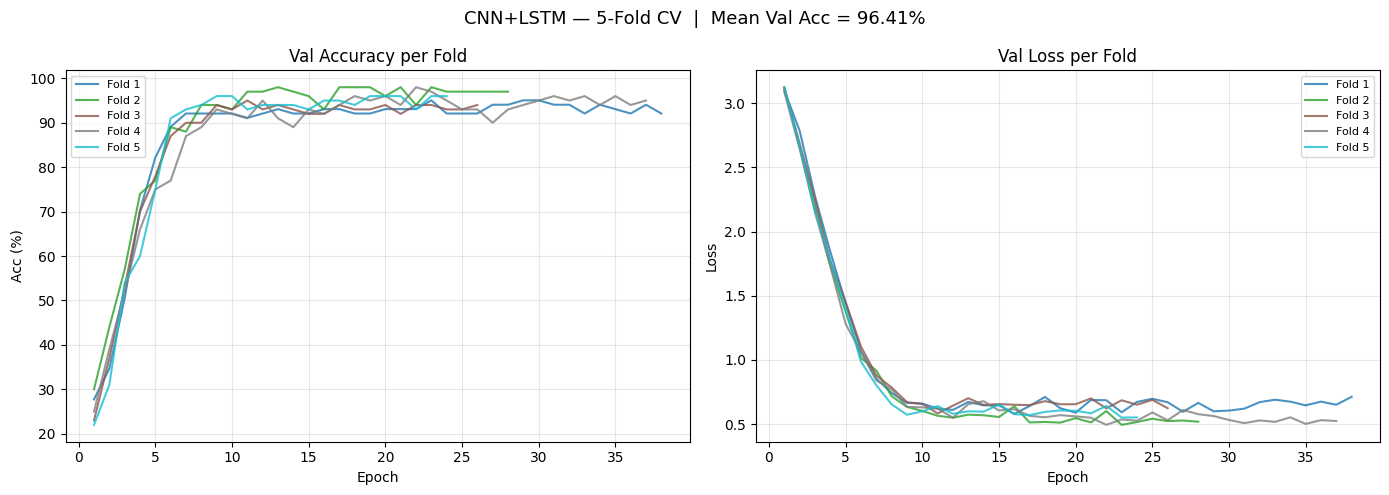

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, K_FOLDS))

for i, hist in enumerate(fold_histories):
    ep = range(1, len(hist['vl_acc']) + 1)
    axes[0].plot(ep, [a*100 for a in hist['vl_acc']],
                 color=colors[i], label=f'Fold {i+1}', alpha=0.8)
    axes[1].plot(ep, hist['vl_loss'],
                 color=colors[i], label=f'Fold {i+1}', alpha=0.8)

axes[0].set_title('Val Accuracy per Fold');  axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Acc (%)')
axes[1].set_title('Val Loss per Fold');      axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'CNN+LSTM — {K_FOLDS}-Fold CV  |  '
             f'Mean Val Acc = {np.mean(fold_val_accs)*100:.2f}%', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 — Train final model on ALL train+val data, evaluate on held-out test set

Now we use the full train+val split (no fold held out) to train one
final model, then evaluate it once on the locked test set.

In [41]:
# Use 15% of trainval as a small validation set just for early stopping
X_tr_f, X_vl_f, y_tr_f, y_vl_f = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15, stratify=y_trainval, random_state=SEED
)

final_model, final_hist, _ = train_model(
    X_tr_f, y_tr_f, X_vl_f, y_vl_f, fold_id=None
)

# ── Test set evaluation ───────────────────────────────────────────────────
test_loader = make_loader(X_test, y_test, shuffle=False)
test_loss, test_acc = run_epoch(test_loader, final_model,
                                nn.CrossEntropyLoss(), train=False)

print(f'\nTest Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')


──── Final ────
  Ep    TrLoss    TrAcc    VlLoss    VlAcc
────────────────────────────────────────────
   1    3.3664    7.88%    3.1444   22.37%
  10    0.6367   95.06%    0.5839   97.37%
  20    0.4521   99.29%    0.4984   97.37%
  30    0.4081   99.88%    0.5082   97.37%
  Early stop at epoch 33
  Best val acc: 98.68%

Test Accuracy : 98.88%
Test Loss     : 0.0761


## Cell 15 — Per-class report and confusion matrix

Per-class report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         3
           B       1.00      1.00      1.00         3
           C       1.00      1.00      1.00         3
           D       1.00      1.00      1.00         3
           E       1.00      1.00      1.00         3
           F       1.00      1.00      1.00         3
           G       1.00      1.00      1.00         3
           H       1.00      1.00      1.00         3
       HELLO       1.00      1.00      1.00         3
           I       1.00      1.00      1.00         3
           J       1.00      1.00      1.00         3
           K       1.00      1.00      1.00         3
           L       1.00      1.00      1.00         3
           M       1.00      1.00      1.00         3
           N       1.00      1.00      1.00         3
          NO       1.00      1.00      1.00         2
           O       1.00      1.00      1.00         3
         

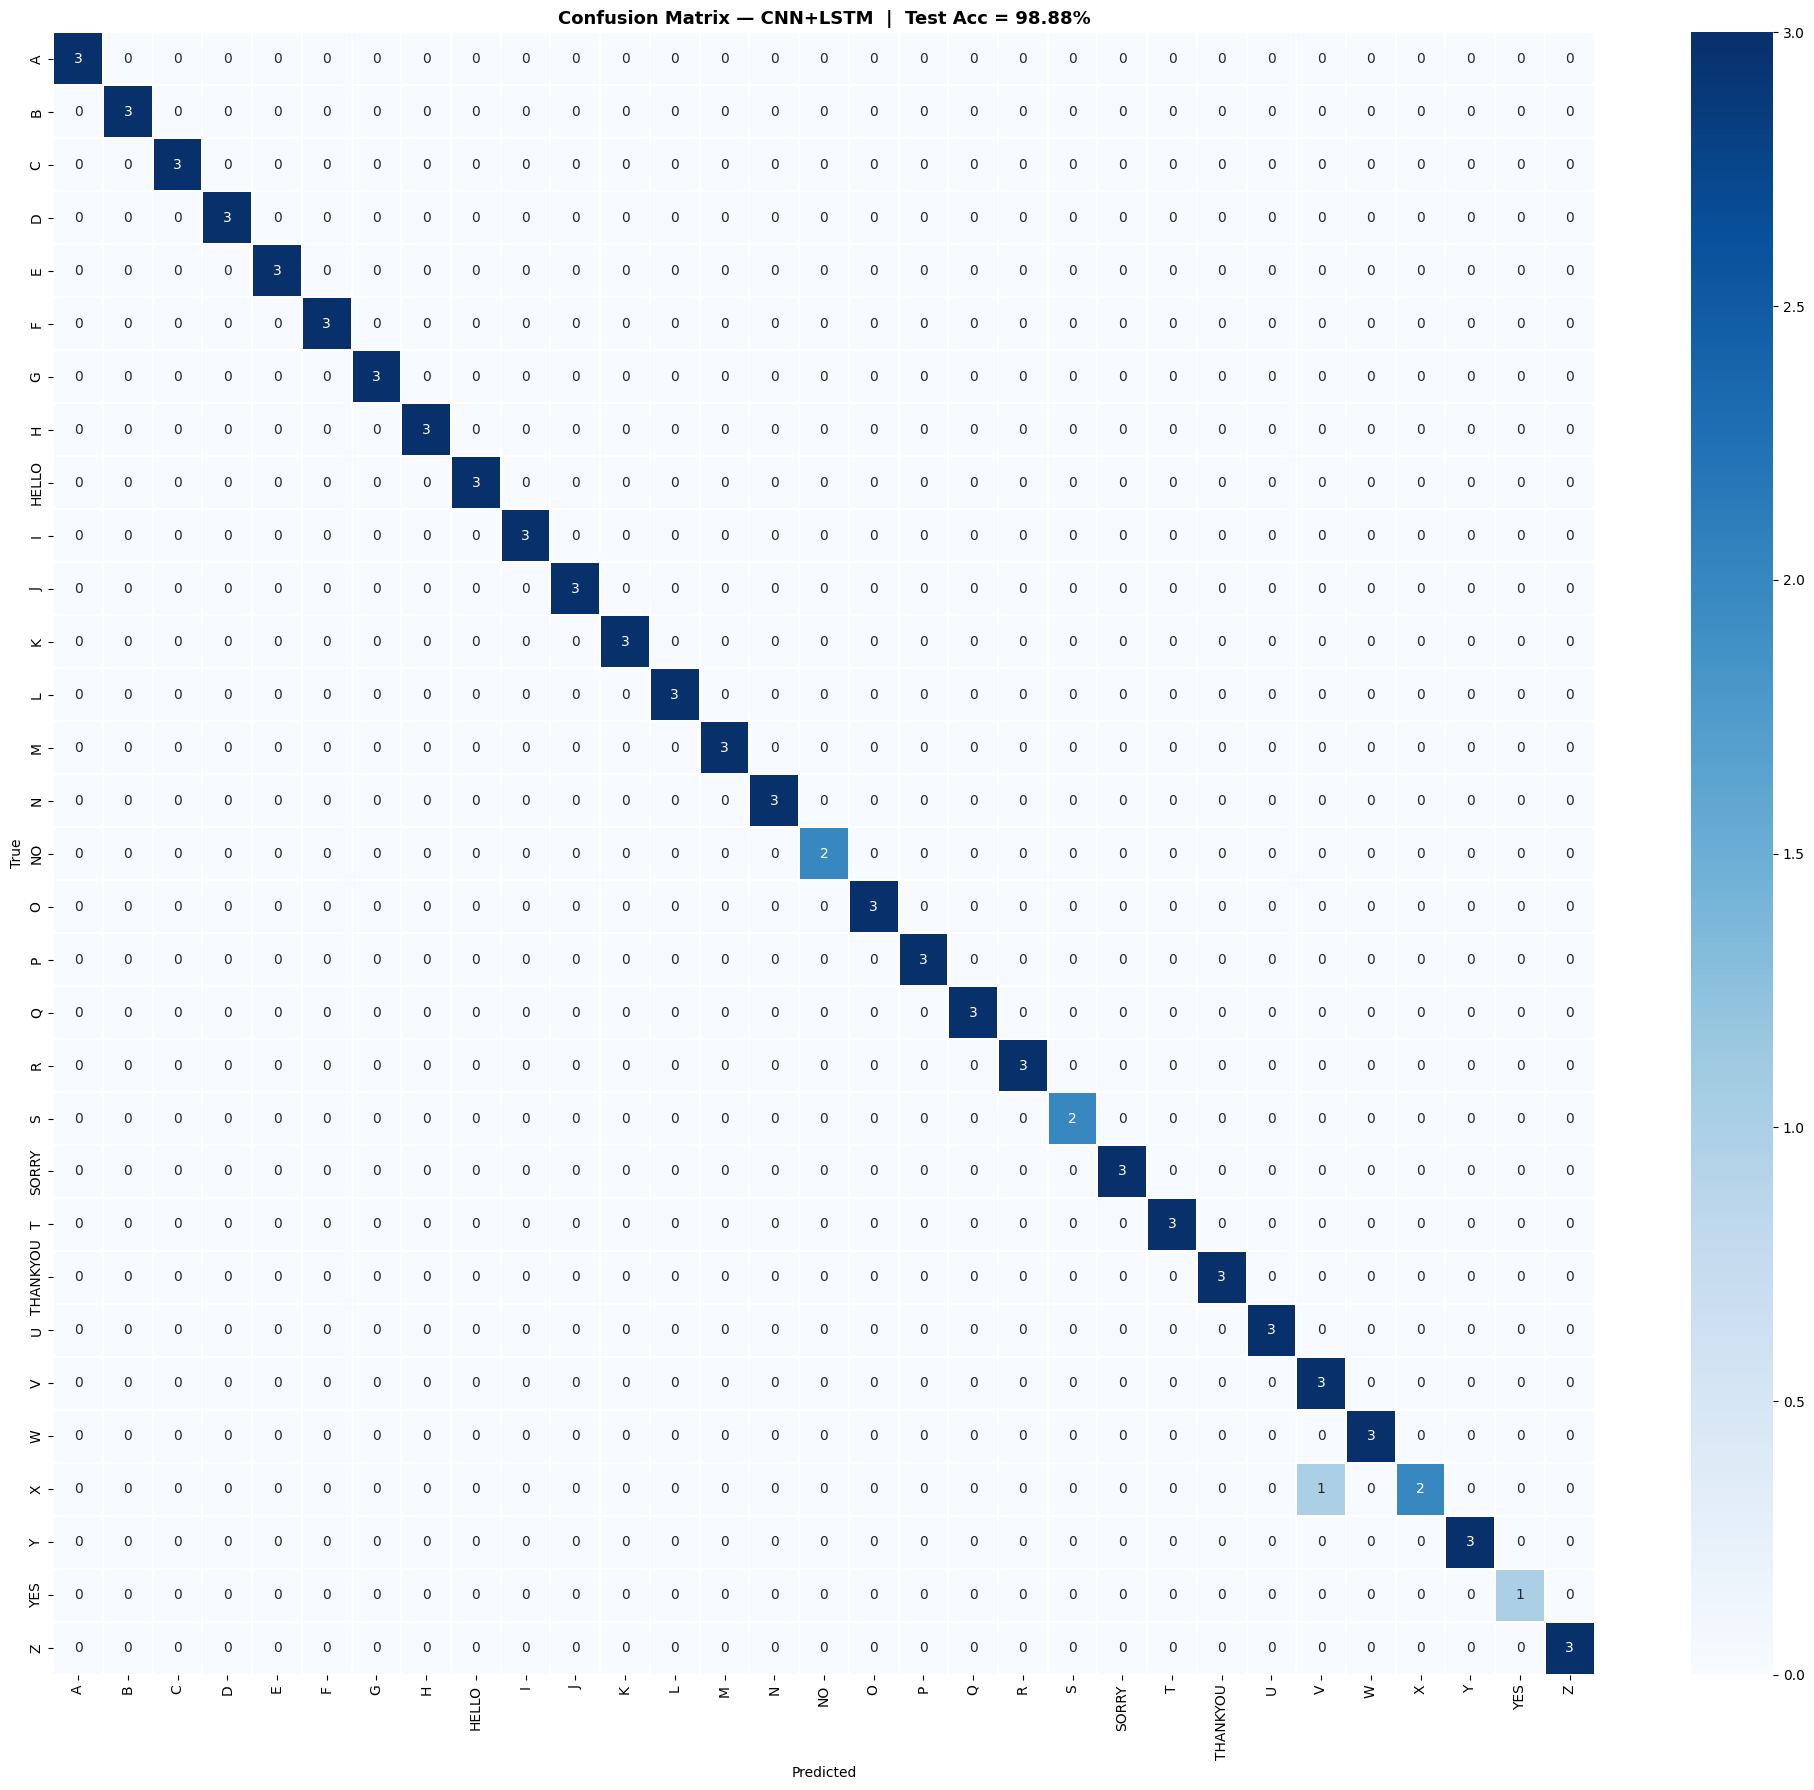

In [42]:
final_model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        preds = final_model(xb.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_true.extend(yb.tolist())

print('Per-class report:')
print(classification_report(
    all_true, all_preds,
    target_names=le.classes_,
    zero_division=0
))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, ax=ax)
ax.set_title(f'Confusion Matrix — CNN+LSTM  |  Test Acc = {test_acc*100:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16 — Save final model

In [43]:
save_path = OUTPUT_DIR / 'cnn_lstm_final.pth'
torch.save({
    'model_state_dict' : final_model.state_dict(),
    'class_names'      : list(le.classes_),
    'num_classes'      : NUM_CLASSES,
    'feature_dim'      : FEATURE_DIM,
    'lstm_hidden'      : LSTM_HIDDEN,
    'lstm_layers'      : LSTM_LAYERS,
    'T'                : T,
    'dropout'          : DROPOUT,
    'cv_mean_acc'      : float(np.mean(fold_val_accs)),
    'test_acc'         : float(test_acc),
}, save_path)

print('Saved artefacts:')
print(f'  {save_path}')
print(f'  {OUTPUT_DIR}/label_encoder.pkl')
print(f'  {OUTPUT_DIR}/cnn_features_X.npy   (re-use without re-extraction)')
print(f'  {OUTPUT_DIR}/cv_curves.png')
print(f'  {OUTPUT_DIR}/confusion_matrix.png')
print(f'\nCV mean acc  : {np.mean(fold_val_accs)*100:.2f}%')
print(f'Test acc     : {test_acc*100:.2f}%')

Saved artefacts:
  /kaggle/working/cnn_lstm_final.pth
  /kaggle/working/label_encoder.pkl
  /kaggle/working/cnn_features_X.npy   (re-use without re-extraction)
  /kaggle/working/cv_curves.png
  /kaggle/working/confusion_matrix.png

CV mean acc  : 96.41%
Test acc     : 98.88%


## Cell 17 — Inference helper (for new videos later)

In [44]:
def predict_video(video_folder: str,
                  lstm_ckpt: str,
                  cnn_weights: str,
                  encoder_path: str,
                  t: int = 16) -> str:
    """
    End-to-end inference on a single video folder.
    Returns the predicted class label string.
    """
    # Load label encoder
    with open(encoder_path, 'rb') as f:
        enc = pickle.load(f)

    # Re-build CNN extractor
    ck_cnn   = torch.load(cnn_weights, map_location=DEVICE)
    cnn_m    = ASLCNN(num_classes=ck_cnn['num_classes']).to(DEVICE)
    cnn_m.load_state_dict(ck_cnn['model_state_dict'])
    ext      = CNNFeatureExtractor(cnn_m).to(DEVICE)
    ext.eval()

    # Re-build LSTM
    ck_lstm = torch.load(lstm_ckpt, map_location=DEVICE)
    lstm_m  = SignLSTM(
        ck_lstm['feature_dim'], ck_lstm['lstm_hidden'],
        ck_lstm['lstm_layers'], ck_lstm['num_classes'],
        ck_lstm['dropout']
    ).to(DEVICE)
    lstm_m.load_state_dict(ck_lstm['model_state_dict'])
    lstm_m.eval()

    # Extract frames → CNN features → LSTM prediction
    frame_paths = sample_frames(Path(video_folder), t)
    imgs = torch.stack([
        frame_transform(Image.open(fp).convert('RGB')) for fp in frame_paths
    ]).to(DEVICE)

    with torch.no_grad():
        feats  = ext(imgs).unsqueeze(0)          # (1, T, 512)
        logits = lstm_m(feats)                   # (1, num_classes)
        pred   = logits.argmax(1).item()

    return enc.inverse_transform([pred])[0]


# Example (uncomment to test):
# result = predict_video(
#     video_folder  = '/kaggle/input/datasets/ep25b021/dataset-2/ASL_dynamic/HELLO/video_01',
#     lstm_ckpt     = '/kaggle/working/cnn_lstm_final.pth',
#     cnn_weights   = '/kaggle/input/datasets/ep25b021/cnn-weights/asl_cnn_weights.pth',
#     encoder_path  = '/kaggle/working/label_encoder.pkl',
# )
# print('Predicted:', result)